# Failure Analysis: SAE-Based Investigation of Probe Errors

Mechanistic analysis of why activation probes fail using Sparse Autoencoders (Llama Scope).

**Research Questions:**
1. Why do probes fail? (Specific features/patterns)
2. Are failures interpretable? (SAE feature explanations)
3. Are failures systematic? (Clusters vs random)
4. Does language matter? (EN vs ID mechanisms)

**Methodology:**
- Load probe predictions from notebook 05 results
- Categorize failures: consistent (EN+ID wrong) vs language-specific
- Extract SAE features for failure cases
- Map failures to interpretable features via Neuronpedia

**Based on paper failure modes (arXiv:2506.10805):**
- Signal word false positives (e.g., "emergency" triggers high-stakes)
- Humor masking (jokes reduce probe scores)
- Ethical framing ("responsible money laundering")
- Context mixing (high-stakes buried in low-stakes)

## Part 0: Setup

In [1]:
import importlib
missing = [pkg for pkg in ["umap", "sae_lens"] if not importlib.util.find_spec(pkg)]
if missing:
    %pip install -U umap-learn sae-lens

/home/ubuntu/default-filesystem/bluedot-project/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
import torch
import umap
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

sys.path.insert(0, str(Path("..").resolve()))

from lib.env import resolve_base_dir, setup_paths, setup_hf_auth
from lib.data import load_dataset, load_jsonl
from lib.model import load_model, get_model_short_name
from lib.probe import LinearProbe
from lib.neuronpedia import fetch_explanations, llama_scope_sae_id, format_feature_with_explanation

# --- Configuration ---
MODEL_NAME      = "meta-llama/Llama-3.1-8B-Instruct"
LAYER           = 12  # UPDATE: Best layer from notebook 05 results (was 16)
EVAL_INDONESIAN = True
RANDOM_SEED     = 42
SAE_EXPANSION   = "8x"  # 32K features

# Derived
BASE_DIR     = resolve_base_dir()
paths        = setup_paths(BASE_DIR)
DATA_DIR     = paths["data_dir"]
CACHE_DIR    = paths["cache_dir"]
MODEL_SHORT  = get_model_short_name(MODEL_NAME)
CACHE_PREFIX = f"v2b_{MODEL_SHORT}"
SAE_ID       = f"fnlp/Llama3_1-8B-Base-L{LAYER}R-{SAE_EXPANSION}"

# Neuronpedia IDs
NEURONPEDIA_MODEL_ID = "llama3.1-8b"  # Llama Scope uses this format
NEURONPEDIA_SAE_ID   = llama_scope_sae_id(LAYER, SAE_EXPANSION)

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"Model:       {MODEL_NAME}")
print(f"Layer:       {LAYER}")
print(f"Cache:       {CACHE_PREFIX}")
print(f"SAE:         {SAE_ID}")
print(f"Neuronpedia: {NEURONPEDIA_MODEL_ID}/{NEURONPEDIA_SAE_ID}")
print(f"Indonesian:  {EVAL_INDONESIAN}")

Model:       meta-llama/Llama-3.1-8B-Instruct
Layer:       12
Cache:       v2b_llama31_8b
SAE:         fnlp/Llama3_1-8B-Base-L12R-8x
Neuronpedia: llama3.1-8b/12-llamascope-res-32k
Indonesian:  True


## Part 1: Load Results & Identify Failures

In [6]:
# Load datasets
from lib.data import ensure_datasets, get_dataset_paths
DATASET_PATHS = ensure_datasets(DATA_DIR)

test_data      = load_dataset(DATASET_PATHS["test"])
anthropic_test = load_dataset(DATASET_PATHS["anthropic_test"])
toolace_test   = load_dataset(DATASET_PATHS["toolace_test"])

# Load activations
X_test      = np.load(CACHE_DIR / f"{CACHE_PREFIX}_test_synthetic_layer{LAYER}.npy")
X_anthropic = np.load(CACHE_DIR / f"{CACHE_PREFIX}_anthropic_test_layer{LAYER}.npy")
X_toolace   = np.load(CACHE_DIR / f"{CACHE_PREFIX}_toolace_test_layer{LAYER}.npy")

y_test      = np.array([e.label for e in test_data])
y_anthropic = np.array([e.label for e in anthropic_test])
y_toolace   = np.array([e.label for e in toolace_test])

# Load probe
probe = LinearProbe.load(CACHE_DIR / f"{CACHE_PREFIX}_probe_layer{LAYER}.pkl")

print(f"Loaded {len(test_data)} test, {len(anthropic_test)} anthropic, {len(toolace_test)} toolace examples")
print(f"Activations shape: {X_test.shape}")
print(f"Probe loaded from layer {LAYER}")

Checking datasets...
  Already exists: train.jsonl
  Already exists: test.jsonl
  Already exists: anthropic_test_balanced_apr_23.jsonl
  Already exists: toolace_test_balanced_apr_22.jsonl
All datasets ready.
Loaded 2000 test, 2984 anthropic, 734 toolace examples
Activations shape: (2000, 4096)
Probe loaded from layer 12


In [7]:
# Get predictions for all datasets
probs_test      = probe.predict_proba(X_test)
probs_anthropic = probe.predict_proba(X_anthropic)
probs_toolace   = probe.predict_proba(X_toolace)

preds_test      = (probs_test >= 0.5).astype(int)
preds_anthropic = (probs_anthropic >= 0.5).astype(int)
preds_toolace   = (probs_toolace >= 0.5).astype(int)

# Identify errors
errors_test      = (preds_test != y_test)
errors_anthropic = (preds_anthropic != y_anthropic)
errors_toolace   = (preds_toolace != y_toolace)

# False positives and negatives
fp_test = (preds_test == 1) & (y_test == 0)
fn_test = (preds_test == 0) & (y_test == 1)
fp_anthropic = (preds_anthropic == 1) & (y_anthropic == 0)
fn_anthropic = (preds_anthropic == 0) & (y_anthropic == 1)
fp_toolace = (preds_toolace == 1) & (y_toolace == 0)
fn_toolace = (preds_toolace == 0) & (y_toolace == 1)

print(f"\nEN Synthetic:  {errors_test.sum():4d} errors ({fp_test.sum()} FP, {fn_test.sum()} FN)")
print(f"EN Anthropic:  {errors_anthropic.sum():4d} errors ({fp_anthropic.sum()} FP, {fn_anthropic.sum()} FN)")
print(f"EN ToolACE:    {errors_toolace.sum():4d} errors ({fp_toolace.sum()} FP, {fn_toolace.sum()} FN)")


EN Synthetic:    55 errors (36 FP, 19 FN)
EN Anthropic:   691 errors (219 FP, 472 FN)
EN ToolACE:     201 errors (43 FP, 158 FN)


In [8]:
# Indonesian data (if enabled)
if EVAL_INDONESIAN:
    ID_DIR = DATA_DIR / "indonesian"
    
    # Filter refusals (same logic as notebook 05)
    def filter_refusals(id_examples, en_examples):
        filtered = []
        for id_ex, en_ex in zip(id_examples, en_examples):
            id_text = next((m["content"] for m in id_ex.messages if m["role"] == "user"), "")
            en_text = next((m["content"] for m in en_ex.messages if m["role"] == "user"), "")
            if id_text != en_text:
                filtered.append(id_ex)
        return filtered
    
    id_test_data_raw  = load_dataset(ID_DIR / "synthetic_test_id.jsonl")
    id_anthropic_raw  = load_dataset(ID_DIR / "anthropic_test_id.jsonl")
    id_toolace_raw    = load_dataset(ID_DIR / "toolace_test_id.jsonl")
    
    id_test_data      = filter_refusals(id_test_data_raw, test_data)
    id_anthropic_test = filter_refusals(id_anthropic_raw, anthropic_test)
    id_toolace_test   = filter_refusals(id_toolace_raw, toolace_test)
    
    # Load Indonesian activations
    X_id_test      = np.load(CACHE_DIR / f"{CACHE_PREFIX}_id_test_synthetic_layer{LAYER}.npy")
    X_id_anthropic = np.load(CACHE_DIR / f"{CACHE_PREFIX}_id_anthropic_test_layer{LAYER}.npy")
    X_id_toolace   = np.load(CACHE_DIR / f"{CACHE_PREFIX}_id_toolace_test_layer{LAYER}.npy")
    
    y_id_test      = np.array([e.label for e in id_test_data])
    y_id_anthropic = np.array([e.label for e in id_anthropic_test])
    y_id_toolace   = np.array([e.label for e in id_toolace_test])
    
    # Predictions
    probs_id_test      = probe.predict_proba(X_id_test)
    probs_id_anthropic = probe.predict_proba(X_id_anthropic)
    probs_id_toolace   = probe.predict_proba(X_id_toolace)
    
    preds_id_test      = (probs_id_test >= 0.5).astype(int)
    preds_id_anthropic = (probs_id_anthropic >= 0.5).astype(int)
    preds_id_toolace   = (probs_id_toolace >= 0.5).astype(int)
    
    errors_id_test      = (preds_id_test != y_id_test)
    errors_id_anthropic = (preds_id_anthropic != y_id_anthropic)
    errors_id_toolace   = (preds_id_toolace != y_id_toolace)
    
    fp_id_test = (preds_id_test == 1) & (y_id_test == 0)
    fn_id_test = (preds_id_test == 0) & (y_id_test == 1)
    fp_id_anthropic = (preds_id_anthropic == 1) & (y_id_anthropic == 0)
    fn_id_anthropic = (preds_id_anthropic == 0) & (y_id_anthropic == 1)
    fp_id_toolace = (preds_id_toolace == 1) & (y_id_toolace == 0)
    fn_id_toolace = (preds_id_toolace == 0) & (y_id_toolace == 1)
    
    print(f"\nID Synthetic:  {errors_id_test.sum():4d} errors ({fp_id_test.sum()} FP, {fn_id_test.sum()} FN)")
    print(f"ID Anthropic:  {errors_id_anthropic.sum():4d} errors ({fp_id_anthropic.sum()} FP, {fn_id_anthropic.sum()} FN)")
    print(f"ID ToolACE:    {errors_id_toolace.sum():4d} errors ({fp_id_toolace.sum()} FP, {fn_id_toolace.sum()} FN)")


ID Synthetic:    73 errors (35 FP, 38 FN)
ID Anthropic:   782 errors (321 FP, 461 FN)
ID ToolACE:     190 errors (21 FP, 169 FN)


## Part 2: Cross-Lingual Flip Analysis

Identify examples where EN and ID probes disagree:
- **EN correct, ID wrong:** Language-specific Indonesian failures
- **EN wrong, ID correct:** Language-specific English failures
- **Both wrong:** Consistent failures (semantic, not linguistic)

In [9]:
if EVAL_INDONESIAN:
    # Align EN/ID examples (after refusal filtering)
    # ID data is subset of EN after filtering, need to map back
    
    # For synthetic test: use IDs to align
    en_ids = [e.id for e in test_data]
    id_ids = [e.id for e in id_test_data]
    id_to_en_idx = {id_: i for i, id_ in enumerate(en_ids)}
    
    aligned_indices = []
    for i, id_ in enumerate(id_ids):
        if id_ in id_to_en_idx:
            aligned_indices.append((id_to_en_idx[id_], i))
    
    en_indices, id_indices = zip(*aligned_indices)
    
    en_correct_aligned = ~errors_test[list(en_indices)]
    id_correct_aligned = ~errors_id_test[list(id_indices)]
    
    both_correct = en_correct_aligned & id_correct_aligned
    both_wrong   = ~en_correct_aligned & ~id_correct_aligned
    en_ok_id_fail = en_correct_aligned & ~id_correct_aligned
    en_fail_id_ok = ~en_correct_aligned & id_correct_aligned
    
    print(f"\nCross-Lingual Agreement (Synthetic Test, n={len(aligned_indices)}):")
    print(f"  Both correct:       {both_correct.sum():4d} ({100*both_correct.sum()/len(aligned_indices):.1f}%)")
    print(f"  Both wrong:         {both_wrong.sum():4d} ({100*both_wrong.sum()/len(aligned_indices):.1f}%)")
    print(f"  EN correct, ID fail: {en_ok_id_fail.sum():4d} ({100*en_ok_id_fail.sum()/len(aligned_indices):.1f}%)")
    print(f"  EN fail, ID correct: {en_fail_id_ok.sum():4d} ({100*en_fail_id_ok.sum()/len(aligned_indices):.1f}%)")
    
    # Store flip indices for later analysis
    flip_en_ok_id_fail_idx = [aligned_indices[i][0] for i in range(len(aligned_indices)) if en_ok_id_fail[i]]
    flip_en_fail_id_ok_idx = [aligned_indices[i][0] for i in range(len(aligned_indices)) if en_fail_id_ok[i]]
    both_wrong_idx         = [aligned_indices[i][0] for i in range(len(aligned_indices)) if both_wrong[i]]


Cross-Lingual Agreement (Synthetic Test, n=1950):
  Both correct:       1859 (95.3%)
  Both wrong:           38 (1.9%)
  EN correct, ID fail:   35 (1.8%)
  EN fail, ID correct:   18 (0.9%)


## Part 3: Activation-Level Analysis (No SAE)

Before diving into SAE features, check if failures are distinguishable in raw activation space.

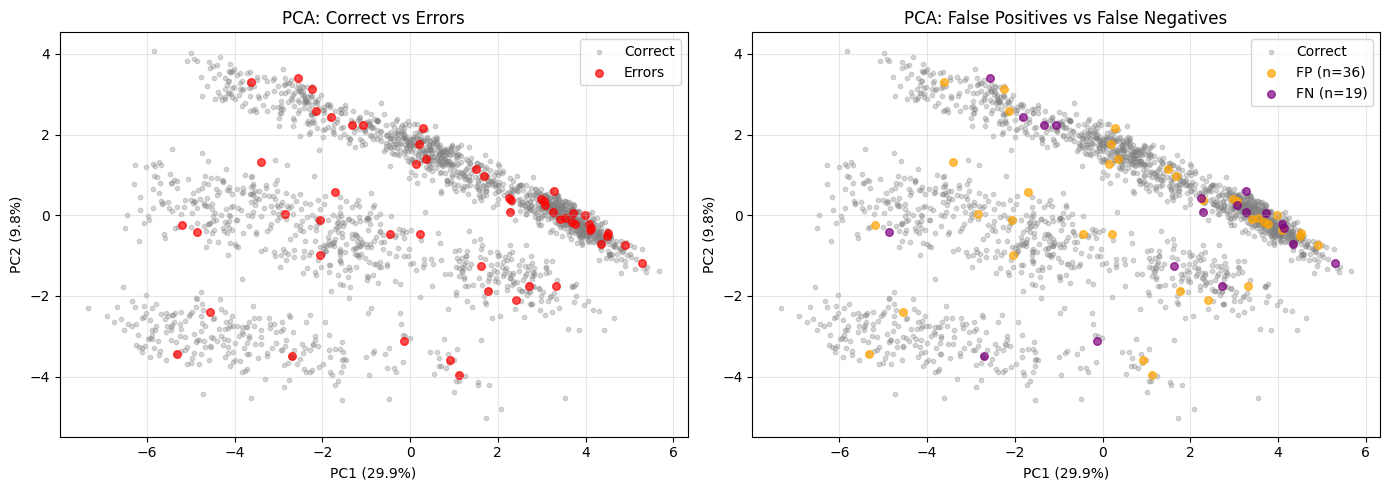


PCA explained variance: 39.6% (first 2 components)


In [10]:
# PCA: Linear separability check
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_test_pca = pca.fit_transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Correct vs errors
ax = axes[0]
ax.scatter(X_test_pca[~errors_test, 0], X_test_pca[~errors_test, 1], 
           c='gray', s=10, alpha=0.3, label='Correct')
ax.scatter(X_test_pca[errors_test, 0], X_test_pca[errors_test, 1], 
           c='red', s=30, alpha=0.7, label='Errors')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA: Correct vs Errors')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: FP vs FN
ax = axes[1]
ax.scatter(X_test_pca[~errors_test, 0], X_test_pca[~errors_test, 1], 
           c='gray', s=10, alpha=0.3, label='Correct')
ax.scatter(X_test_pca[fp_test, 0], X_test_pca[fp_test, 1], 
           c='orange', s=30, alpha=0.7, label=f'FP (n={fp_test.sum()})')
ax.scatter(X_test_pca[fn_test, 0], X_test_pca[fn_test, 1], 
           c='purple', s=30, alpha=0.7, label=f'FN (n={fn_test.sum()})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA: False Positives vs False Negatives')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CACHE_DIR / f"{CACHE_PREFIX}_pca_failures_layer{LAYER}.png", dpi=150)
plt.show()

print(f"\nPCA explained variance: {pca.explained_variance_ratio_[:2].sum():.1%} (first 2 components)")

Computing UMAP embedding (may take 1-2 min)...


/home/ubuntu/default-filesystem/bluedot-project/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


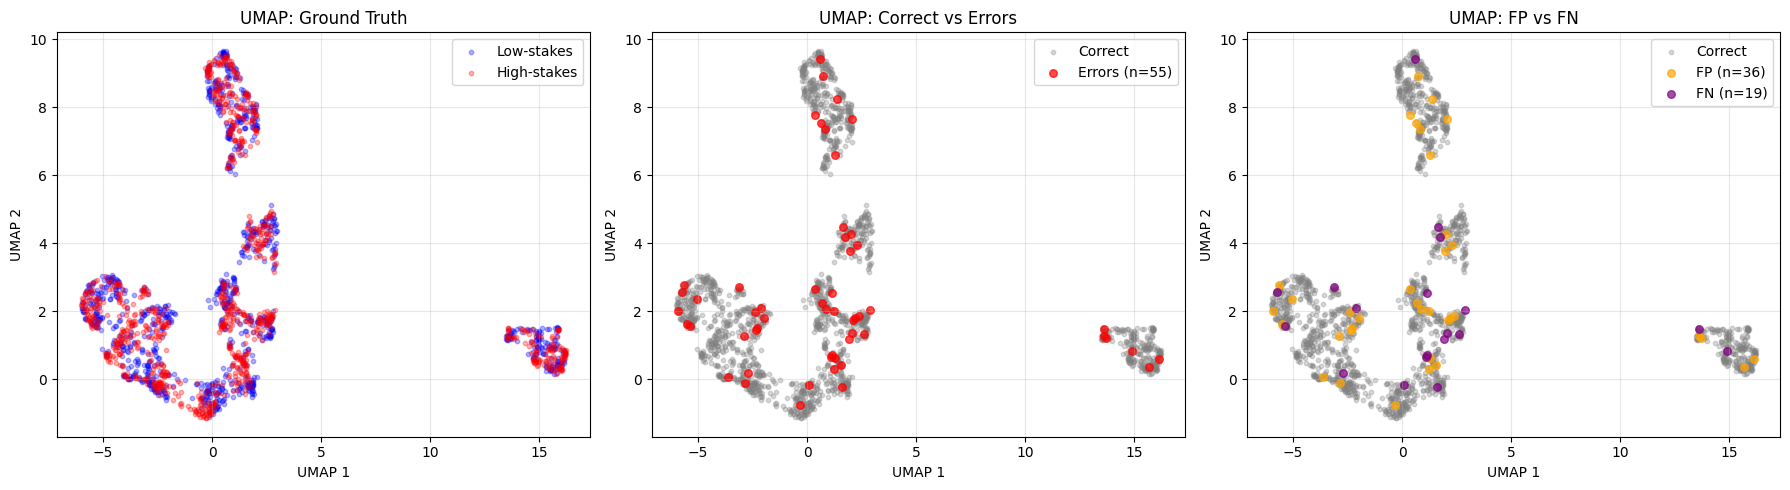

In [11]:
# UMAP: Non-linear clustering
print("Computing UMAP embedding (may take 1-2 min)...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED, verbose=False)
X_test_umap = reducer.fit_transform(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Ground truth labels
ax = axes[0]
ax.scatter(X_test_umap[y_test == 0, 0], X_test_umap[y_test == 0, 1], 
           c='blue', s=10, alpha=0.3, label='Low-stakes')
ax.scatter(X_test_umap[y_test == 1, 0], X_test_umap[y_test == 1, 1], 
           c='red', s=10, alpha=0.3, label='High-stakes')
ax.set_title('UMAP: Ground Truth')
ax.legend()

# Plot 2: Correct vs errors
ax = axes[1]
ax.scatter(X_test_umap[~errors_test, 0], X_test_umap[~errors_test, 1], 
           c='gray', s=10, alpha=0.3, label='Correct')
ax.scatter(X_test_umap[errors_test, 0], X_test_umap[errors_test, 1], 
           c='red', s=30, alpha=0.7, label=f'Errors (n={errors_test.sum()})')
ax.set_title('UMAP: Correct vs Errors')
ax.legend()

# Plot 3: FP vs FN
ax = axes[2]
ax.scatter(X_test_umap[~errors_test, 0], X_test_umap[~errors_test, 1], 
           c='gray', s=10, alpha=0.3, label='Correct')
ax.scatter(X_test_umap[fp_test, 0], X_test_umap[fp_test, 1], 
           c='orange', s=30, alpha=0.7, label=f'FP (n={fp_test.sum()})')
ax.scatter(X_test_umap[fn_test, 0], X_test_umap[fn_test, 1], 
           c='purple', s=30, alpha=0.7, label=f'FN (n={fn_test.sum()})')
ax.set_title('UMAP: FP vs FN')
ax.legend()

for ax in axes:
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CACHE_DIR / f"{CACHE_PREFIX}_umap_failures_layer{LAYER}.png", dpi=150)
plt.show()

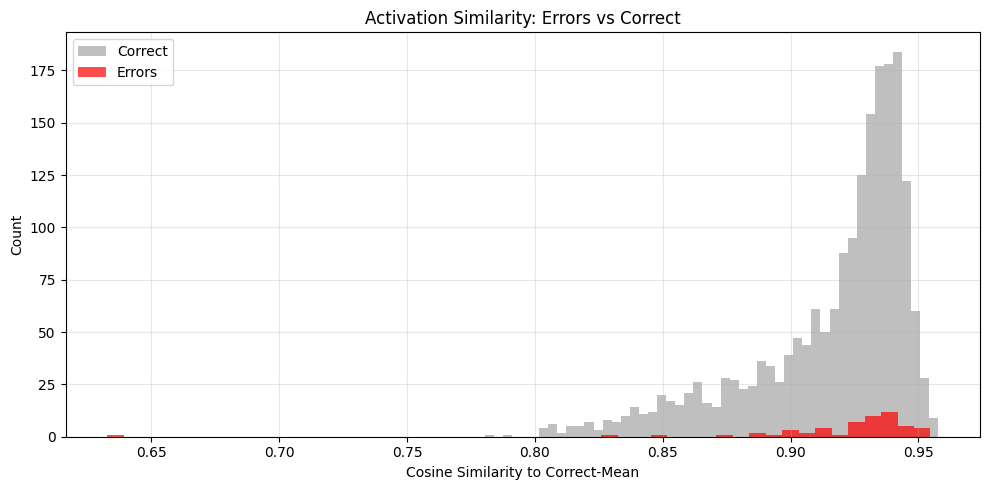


Cosine Similarity to Correct-Mean:
  Correct predictions: 0.9161 ± 0.0315
  Errors:              0.9186 ± 0.0459


In [12]:
# Cosine similarity: errors vs correct predictions
from sklearn.metrics.pairwise import cosine_similarity

X_correct = X_test[~errors_test]
X_errors  = X_test[errors_test]

# Compute mean activation for correct predictions
X_correct_mean = X_correct.mean(axis=0, keepdims=True)

# Cosine similarity of errors to correct-mean
cos_sim_errors = cosine_similarity(X_errors, X_correct_mean).flatten()
cos_sim_correct = cosine_similarity(X_correct, X_correct_mean).flatten()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(cos_sim_correct, bins=50, alpha=0.5, label='Correct', color='gray')
ax.hist(cos_sim_errors, bins=50, alpha=0.7, label='Errors', color='red')
ax.set_xlabel('Cosine Similarity to Correct-Mean')
ax.set_ylabel('Count')
ax.set_title('Activation Similarity: Errors vs Correct')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CACHE_DIR / f"{CACHE_PREFIX}_cosine_sim_layer{LAYER}.png", dpi=150)
plt.show()

print(f"\nCosine Similarity to Correct-Mean:")
print(f"  Correct predictions: {cos_sim_correct.mean():.4f} ± {cos_sim_correct.std():.4f}")
print(f"  Errors:              {cos_sim_errors.mean():.4f} ± {cos_sim_errors.std():.4f}")

## Part 4: Load SAE and Extract Features

Load Llama Scope SAE (32K features, layer 12 residual stream) and encode activations.

**Note:** Llama Scope SAEs are trained on **Llama-3.1-8B-Base**, not the Instruct variant we use for activation extraction. The Llama Scope paper (arXiv:2410.20526) evaluated this cross-model transfer and found no significant degradation in reconstruction quality for layers 0-30. Only layer 31 (final layer) shows issues. Our layer 12 is well within the safe range.

In [17]:
# Load SAE from Llama Scope via SAE Lens
# Note: Llama Scope SAEs are trained on the Base model, not Instruct.
# The paper (arXiv:2410.20526) shows negligible degradation when applying
# Base SAEs to Instruct models for layers 0-30. Layer 12 is safe.
from sae_lens import SAE

setup_hf_auth()  # Ensure HF token is set

# SAE Lens release names (from pretrained_saes.yaml):
#   "llama_scope_lxr_8x"  -> fnlp/Llama3_1-8B-Base-LXR-8x  (residual, 32K features)
#   "llama_scope_lxr_32x" -> fnlp/Llama3_1-8B-Base-LXR-32x (residual, 128K features)
# SAE ID format: "l{layer}r_{expansion}" e.g. "l12r_8x"

SAE_RELEASE  = f"llama_scope_lxr_{SAE_EXPANSION}"      # e.g. "llama_scope_lxr_8x"
SAE_LENS_ID  = f"l{LAYER}r_{SAE_EXPANSION}"             # e.g. "l12r_8x"

print(f"Loading SAE: {SAE_RELEASE} / {SAE_LENS_ID}")
print(f"(HF repo: fnlp/Llama3_1-8B-Base-LXR-{SAE_EXPANSION})")
print("(This may take 1-2 minutes on first download)")

device = "cuda" if torch.cuda.is_available() else "cpu"
sae = SAE.from_pretrained(
    release=SAE_RELEASE,
    sae_id=SAE_LENS_ID,
    device=device
)

n_features = sae.cfg.d_sae
print(f"Loaded SAE with {n_features} features")
print(f"Device: {device}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to HuggingFace
Loading SAE: llama_scope_lxr_8x / l12r_8x
(HF repo: fnlp/Llama3_1-8B-Base-LXR-8x)
(This may take 1-2 minutes on first download)


hyperparams.json: 0.00B [00:00, ?B/s]

Llama3_1-8B-Base-L12R-8x/checkpoints/fin(…):   0%|          | 0.00/537M [00:00<?, ?B/s]

Loaded SAE with 32768 features
Device: cuda


In [18]:
# Encode activations -> SAE features
def encode_batch(X, batch_size=256):
    """Encode activations in batches to avoid OOM."""
    features = []
    for i in range(0, len(X), batch_size):
        X_batch = torch.tensor(X[i:i+batch_size], dtype=torch.float32, device=device)
        with torch.no_grad():
            f_batch = sae.encode(X_batch).cpu().numpy()
        features.append(f_batch)
    return np.vstack(features)

print("Encoding synthetic test activations...")
F_test = encode_batch(X_test)
print(f"SAE features shape: {F_test.shape}")
print(f"Sparsity (L0): {(F_test > 0).sum(axis=1).mean():.1f} features/example")

Encoding synthetic test activations...
SAE features shape: (2000, 32768)
Sparsity (L0): 1.9 features/example


## Part 5: Feature Analysis for Failures

Extract top-k active features for each failure case.

In [19]:
# Extract top-k features for errors
TOP_K = 10

def get_top_features(feature_matrix, indices, k=TOP_K):
    """Get top-k active features for given indices."""
    top_features = []
    for i in indices:
        f = feature_matrix[i]
        top_idx = np.argsort(f)[-k:][::-1]  # Top-k indices (descending)
        top_val = f[top_idx]
        top_features.append((top_idx, top_val))
    return top_features

# Get top features for FP and FN
fp_indices = np.where(fp_test)[0]
fn_indices = np.where(fn_test)[0]

fp_top_features = get_top_features(F_test, fp_indices)
fn_top_features = get_top_features(F_test, fn_indices)

print(f"Extracted top-{TOP_K} features for {len(fp_indices)} FP and {len(fn_indices)} FN cases")

Extracted top-10 features for 36 FP and 19 FN cases


In [20]:
# Feature frequency analysis: Which features are most common in failures?
def get_feature_counts(top_features_list):
    """Count how often each feature appears in top-k."""
    counts = Counter()
    for top_idx, top_val in top_features_list:
        counts.update(top_idx)
    return counts

fp_feature_counts = get_feature_counts(fp_top_features)
fn_feature_counts = get_feature_counts(fn_top_features)

print(f"\nTop-10 most common features in FALSE POSITIVES:")
for feat_id, count in fp_feature_counts.most_common(10):
    print(f"  Feature {feat_id:5d}: appears in {count}/{len(fp_indices)} FP cases ({100*count/len(fp_indices):.1f}%)")

print(f"\nTop-10 most common features in FALSE NEGATIVES:")
for feat_id, count in fn_feature_counts.most_common(10):
    print(f"  Feature {feat_id:5d}: appears in {count}/{len(fn_indices)} FN cases ({100*count/len(fn_indices):.1f}%)")


Top-10 most common features in FALSE POSITIVES:
  Feature 10921: appears in 36/36 FP cases (100.0%)
  Feature   604: appears in 34/36 FP cases (94.4%)
  Feature 10922: appears in 34/36 FP cases (94.4%)
  Feature 10915: appears in 32/36 FP cases (88.9%)
  Feature 10916: appears in 32/36 FP cases (88.9%)
  Feature 10917: appears in 32/36 FP cases (88.9%)
  Feature 10918: appears in 32/36 FP cases (88.9%)
  Feature 10919: appears in 32/36 FP cases (88.9%)
  Feature 10920: appears in 32/36 FP cases (88.9%)
  Feature 19230: appears in 31/36 FP cases (86.1%)

Top-10 most common features in FALSE NEGATIVES:
  Feature 10921: appears in 19/19 FN cases (100.0%)
  Feature 10922: appears in 19/19 FN cases (100.0%)
  Feature 19230: appears in 18/19 FN cases (94.7%)
  Feature   604: appears in 18/19 FN cases (94.7%)
  Feature 10915: appears in 16/19 FN cases (84.2%)
  Feature 10916: appears in 16/19 FN cases (84.2%)
  Feature 10917: appears in 16/19 FN cases (84.2%)
  Feature 10918: appears in 16/1

In [21]:
# Feature activation strength: Sum of activations per feature across all failures
def get_feature_activation_sums(feature_matrix, indices):
    """Sum activation strength per feature across given indices."""
    return feature_matrix[indices].sum(axis=0)

fp_feature_sums = get_feature_activation_sums(F_test, fp_indices)
fn_feature_sums = get_feature_activation_sums(F_test, fn_indices)

top_fp_by_strength = np.argsort(fp_feature_sums)[-10:][::-1]
top_fn_by_strength = np.argsort(fn_feature_sums)[-10:][::-1]

print(f"\nTop-10 features by ACTIVATION STRENGTH in FALSE POSITIVES:")
for feat_id in top_fp_by_strength:
    print(f"  Feature {feat_id:5d}: total activation = {fp_feature_sums[feat_id]:.2f}")

print(f"\nTop-10 features by ACTIVATION STRENGTH in FALSE NEGATIVES:")
for feat_id in top_fn_by_strength:
    print(f"  Feature {feat_id:5d}: total activation = {fn_feature_sums[feat_id]:.2f}")


Top-10 features by ACTIVATION STRENGTH in FALSE POSITIVES:
  Feature   604: total activation = 117.82
  Feature 19230: total activation = 91.28
  Feature 17722: total activation = 9.78
  Feature 10927: total activation = 0.00
  Feature 10926: total activation = 0.00
  Feature 10925: total activation = 0.00
  Feature 10924: total activation = 0.00
  Feature 10923: total activation = 0.00
  Feature 10922: total activation = 0.00
  Feature 10921: total activation = 0.00

Top-10 features by ACTIVATION STRENGTH in FALSE NEGATIVES:
  Feature   604: total activation = 60.39
  Feature 19230: total activation = 54.03
  Feature 17722: total activation = 6.66
  Feature 10927: total activation = 0.00
  Feature 10926: total activation = 0.00
  Feature 10925: total activation = 0.00
  Feature 10924: total activation = 0.00
  Feature 10923: total activation = 0.00
  Feature 10922: total activation = 0.00
  Feature 10921: total activation = 0.00


## Part 6: Interpret Features via Neuronpedia

Look up top features on Neuronpedia to understand what they represent.

**Manual step:** Visit https://www.neuronpedia.org/llama-scope and search for feature IDs.

For automation, we'll create a summary table with Neuronpedia links.

In [22]:
# Fetch explanations from Neuronpedia API
print("Fetching feature explanations from Neuronpedia...")
explanations = fetch_explanations(
    model_id=NEURONPEDIA_MODEL_ID,
    sae_id=NEURONPEDIA_SAE_ID,
    cache_dir=CACHE_DIR,
    force_refresh=False
)

print(f"\n{'='*80}")
print(f"FEATURE EXPLANATIONS FOR TOP FAILURE-ASSOCIATED FEATURES")
print(f"{'='*80}")

# Top features to investigate
fp_top_10_freq = [f for f, _ in fp_feature_counts.most_common(10)]
fn_top_10_freq = [f for f, _ in fn_feature_counts.most_common(10)]

print("\n" + "-"*80)
print("FALSE POSITIVE FEATURES (most frequent)")
print("-"*80)
for i, feat_id in enumerate(fp_top_10_freq, 1):
    count = fp_feature_counts[feat_id]
    explanation = explanations.get(feat_id, "No explanation available")
    from lib.neuronpedia import neuronpedia_url
    url = neuronpedia_url(feat_id, NEURONPEDIA_MODEL_ID, NEURONPEDIA_SAE_ID)
    
    print(f"\n{i}. Feature {feat_id} ({count}/{len(fp_indices)} cases = {100*count/len(fp_indices):.1f}%)")
    print(f"   Explanation: {explanation}")
    print(f"   Link: {url}")

print("\n" + "-"*80)
print("FALSE NEGATIVE FEATURES (most frequent)")
print("-"*80)
for i, feat_id in enumerate(fn_top_10_freq, 1):
    count = fn_feature_counts[feat_id]
    explanation = explanations.get(feat_id, "No explanation available")
    url = neuronpedia_url(feat_id, NEURONPEDIA_MODEL_ID, NEURONPEDIA_SAE_ID)
    
    print(f"\n{i}. Feature {feat_id} ({count}/{len(fn_indices)} cases = {100*count/len(fn_indices):.1f}%)")
    print(f"   Explanation: {explanation}")
    print(f"   Link: {url}")

Fetching feature explanations from Neuronpedia...
🌐 Fetching explanations from Neuronpedia API...
   URL: https://www.neuronpedia.org/api/explanation/export?modelId=llama3.1-8b&saeId=12-llamascope-res-32k
❌ Failed to fetch explanations: 404 Client Error: Not Found for url: https://www.neuronpedia.org/api/explanation/export?modelId=llama3.1-8b&saeId=12-llamascope-res-32k

FEATURE EXPLANATIONS FOR TOP FAILURE-ASSOCIATED FEATURES

--------------------------------------------------------------------------------
FALSE POSITIVE FEATURES (most frequent)
--------------------------------------------------------------------------------

1. Feature 10921 (36/36 cases = 100.0%)
   Explanation: No explanation available
   Link: https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/10921

2. Feature 604 (34/36 cases = 94.4%)
   Explanation: No explanation available
   Link: https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/604

3. Feature 10922 (34/36 cases = 94.4%)
   Explanatio

## Part 7: Signal Word Analysis

Identify specific tokens that trigger false positives (like paper's "emergency" example).

In [23]:
# Extract text from false positive examples and look for signal words
import re

# Get FP examples
fp_examples = [test_data[i] for i in fp_indices]

# Extract all text
fp_texts = []
for ex in fp_examples:
    user_msg = next((m["content"] for m in ex.messages if m["role"] == "user"), "")
    fp_texts.append(user_msg)

# Potential signal words (from paper + manual inspection)
signal_words = [
    "emergency", "urgent", "critical", "danger", "crisis", "threat",
    "illegal", "harm", "kill", "attack", "weapon", "terror",
    "hack", "steal", "fraud", "scam", "launder",
]

# Count occurrences
signal_word_counts = Counter()
fp_with_signal = []

for i, text in enumerate(fp_texts):
    text_lower = text.lower()
    for word in signal_words:
        if re.search(rf"\b{word}\b", text_lower):
            signal_word_counts[word] += 1
            fp_with_signal.append((i, word, text[:150]))

print(f"\nSignal Words in False Positives:")
for word, count in signal_word_counts.most_common(15):
    print(f"  '{word}': {count} occurrences ({100*count/len(fp_texts):.1f}% of FPs)")

print(f"\nExample FPs with signal words:")
for i, word, text in fp_with_signal[:5]:
    print(f"\n  [{fp_indices[i]}] Signal: '{word}'")
    print(f"  {text}...")


Signal Words in False Positives:

Example FPs with signal words:


## Part 8: Annotated Failure Examples

Create human-readable summaries of failures with SAE explanations.

In [24]:
# Select diverse failure examples for annotation
np.random.seed(RANDOM_SEED)
sample_fp = np.random.choice(fp_indices, size=min(5, len(fp_indices)), replace=False)
sample_fn = np.random.choice(fn_indices, size=min(5, len(fn_indices)), replace=False)

def annotate_example(idx, example, prob, top_features):
    """Create annotated failure summary with feature explanations."""
    user_msg = next((m["content"] for m in example.messages if m["role"] == "user"), "")
    top_idx, top_val = top_features
    
    print(f"\n{'='*80}")
    print(f"Example ID: {example.id}")
    print(f"Prediction: {prob:.3f} | True label: {example.label}")
    print(f"Text (first 300 chars): {user_msg[:300]}...")
    print(f"\nTop-{TOP_K} SAE Features:")
    for i, (feat_id, val) in enumerate(zip(top_idx, top_val)):
        print(f"  {i+1}. {format_feature_with_explanation(feat_id, val, explanations, NEURONPEDIA_MODEL_ID, NEURONPEDIA_SAE_ID, max_length=120)}")

print("\n" + "#"*80)
print("# ANNOTATED FALSE POSITIVES")
print("#"*80)
for i, idx in enumerate(sample_fp):
    annotate_example(idx, test_data[idx], probs_test[idx], fp_top_features[np.where(fp_indices == idx)[0][0]])

print("\n" + "#"*80)
print("# ANNOTATED FALSE NEGATIVES")
print("#"*80)
for i, idx in enumerate(sample_fn):
    annotate_example(idx, test_data[idx], probs_test[idx], fn_top_features[np.where(fn_indices == idx)[0][0]])


################################################################################
# ANNOTATED FALSE POSITIVES
################################################################################

Example ID: mIPIHSk6
Prediction: 0.678 | True label: 0
Text (first 300 chars): क्या अब तकनीक इतनी जटिल हो गयी है कि यह हमारी जीवनशैली को आसान की जगह और उलझा देती है?...

Top-10 SAE Features:
  1. Feature 19230 (act=2.908): No explanation available. Check: https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/19230
            https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/19230
  2. Feature 10913 (act=0.000): No explanation available. Check: https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/10913
            https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/10913
  3. Feature 10914 (act=0.000): No explanation available. Check: https://www.neuronpedia.org/llama3.1-8b/12-llamascope-res-32k/10914
            https://www.neuronpedia.org/llama3.1-8b/12-lla

## Part 9: Summary & Recommendations

Statistical summary and next steps.

In [25]:
# Save results to JSON
results = {
    "model": MODEL_NAME,
    "layer": LAYER,
    "sae_id": SAE_ID,
    "n_features": int(n_features),
    "error_counts": {
        "synthetic": {"total": int(errors_test.sum()), "fp": int(fp_test.sum()), "fn": int(fn_test.sum())},
        "anthropic": {"total": int(errors_anthropic.sum()), "fp": int(fp_anthropic.sum()), "fn": int(fn_anthropic.sum())},
        "toolace": {"total": int(errors_toolace.sum()), "fp": int(fp_toolace.sum()), "fn": int(fn_toolace.sum())},
    },
    "top_fp_features": [(int(f), int(c)) for f, c in fp_feature_counts.most_common(20)],
    "top_fn_features": [(int(f), int(c)) for f, c in fn_feature_counts.most_common(20)],
    "signal_words": dict(signal_word_counts.most_common(20)),
    "sparsity_l0": float((F_test > 0).sum(axis=1).mean()),
}

if EVAL_INDONESIAN:
    results["cross_lingual"] = {
        "n_aligned": len(aligned_indices),
        "both_correct": int(both_correct.sum()),
        "both_wrong": int(both_wrong.sum()),
        "en_ok_id_fail": int(en_ok_id_fail.sum()),
        "en_fail_id_ok": int(en_fail_id_ok.sum()),
    }

output_path = CACHE_DIR / f"{CACHE_PREFIX}_failure_analysis_layer{LAYER}.json"
with open(output_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"\nResults saved to {output_path.name}")
print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(f"Total failures analyzed: {errors_test.sum()} synthetic, {errors_anthropic.sum()} anthropic, {errors_toolace.sum()} toolace")
print(f"SAE features: {n_features} total, ~{(F_test > 0).sum(axis=1).mean():.1f} active per example")
print(f"Top FP feature appears in {fp_feature_counts.most_common(1)[0][1]}/{len(fp_indices)} FP cases")
print(f"Top FN feature appears in {fn_feature_counts.most_common(1)[0][1]}/{len(fn_indices)} FN cases")
print(f"Signal words found in {len(fp_with_signal)}/{len(fp_texts)} FP cases")


Results saved to v2b_llama31_8b_failure_analysis_layer12.json

SUMMARY
Total failures analyzed: 55 synthetic, 691 anthropic, 201 toolace
SAE features: 32768 total, ~1.9 active per example
Top FP feature appears in 36/36 FP cases
Top FN feature appears in 19/19 FN cases
Signal words found in 0/36 FP cases
